<a href="https://colab.research.google.com/github/mahmudscode/NLP_work/blob/main/NLP_WORK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout,
    Bidirectional,
    LSTM
)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


## 1. Introduction

This section should introduce the problem of Bangla document classification, its importance, challenges specific to the Bengali language, and why explainability in deep learning models is crucial for this task. Briefly mention existing approaches and clearly state the contributions of your research. This will set the context for your conference paper.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os

# Define the target path
target_path = '/content/drive/MyDrive/LLM_BANGLA_DATA/Bangla_newspaper'

# Change the current working directory
os.chdir(target_path)

# Verify the current working directory
print(f"Current working directory: {os.getcwd()}")

Current working directory: /content/drive/MyDrive/LLM_BANGLA_DATA/Bangla_newspaper


In [4]:
import os

for file in os.listdir():
    print(file)

data
data_v2
attention_bilstm_model_architecture.png
best_attention_model.keras
cnn_model_architecture.png
bilstm_model_architecture.png


In [5]:
import os

for root, dirs, files in os.walk("data_v2"):
    print(f"\nFolder: {root}")
    print("Files:", files[:5])
    break


Folder: data_v2
Files: ['data_v2.json']


In [6]:
import os

for root, dirs, files in os.walk("data_v2"):
    if len(files) > 0:
        print("Example file:", os.path.join(root, files[0]))
        break

Example file: data_v2/data_v2.json


In [7]:
import json

with open("data_v2/data_v2.json", "r", encoding="utf-8") as f:
    data = json.load(f)

print(type(data))

<class 'list'>


In [8]:
print(len(data))

408471


In [9]:
data[0]

{'author': 'গাজীপুর প্রতিনিধি',
 'category': 'bangladesh',
 'category_bn': 'বাংলাদেশ',
 'published_date': '০৪ জুলাই ২০১৩, ২৩:২৬',
 'modification_date': '০৪ জুলাই ২০১৩, ২৩:২৭',
 'tag': ['গাজীপুর'],
 'comment_count': 0,
 'title': 'কালিয়াকৈরে টিফিন খেয়ে ৫০০ শ্রমিক অসুস্থ, বিক্ষোভ',
 'url': 'http://www.prothom-alo.com/bangladesh/article/19030',
 'content': 'গাজীপুরের কালিয়াকৈর উপজেলার তেলিরচালা এলাকায় আজ বৃহস্পতিবার রাতের টিফিন খেয়ে একটি পোশাক কারখানার ৫০০ শ্রমিক অসুস্থ হয়ে পড়েছেন। এ ঘটনায় বিক্ষোভ করেছেন ওই কারখানার শ্রমিকেরা।সফিপুর মডার্ন হাসপাতালের জরুরি বিভাগের চিকিত্সক আল আমিন প্রথম আলো ডটকমকে বলেন, খাদ্যে বিষক্রিয়ায় তাঁরা (শ্রমিকেরা) অসুস্থ হয়ে পড়েছেন। এতে আতঙ্কিত হওয়ার কিছু নেই। অসুস্থদের চিকিত্সা দেওয়া হয়েছে।কারখানার শ্রমিক ও পুলিশ সূত্রে জানা যায়, উপজেলার তেলিরচালা এলাকার সেজাদ সোয়েটার লিমিটেড কারখানার শ্রমিকদের আজ রাত সাড়ে সাতটার দিকে টিফিন দেওয়া হয়। টিফিনে ছিল ডিম, রুটি, পেটিস ও কলা। টিফিন খেয়ে শ্রমিকেরা যথারীতি কাজে যোগ দেন। ওই টিফিন খাওয়ার প্রায় এক ঘণ্টা 

In [15]:
import json
import pandas as pd

# The 'data' variable is already loaded from a previous cell (AU95EJfGjG5-).
# No need to open the file again or define a generator that reloads it.

# Take only sample first (VERY IMPORTANT for Colab)
sample_size = 100000

records = []
# Iterate directly over the 'data' list loaded from a previous cell
for i, item in enumerate(data):
    records.append({
        "text": str(item.get("title", "")) + " " + str(item.get("content", "")),
        "category": item.get("category", "")
    })

    if i + 1 >= sample_size:
        break

df = pd.DataFrame(records)

print(df.shape)
df.head()

(100000, 2)


,text,category
0,"কালিয়াকৈরে টিফিন খেয়ে ৫০০ শ্রমিক অসুস্থ, বিক...",bangladesh
1,সেমিফাইনাল বাধাও পেরিয়ে গেলেন লিসিকি এবারের উ...,sports
2,সংসদে খালেদার অভিযোগের জবাব দিয়েছে ভারত জাতীয...,bangladesh
3,পাসওয়ার্ড ভুলে যান! সহজ পাসওয়ার্ডের কারণে অন...,technology
4,চলে গেলেন মাউস উদ্ভাবক কম্পিউটার মাউসের উদ্ভাব...,technology


## 2. Dataset and Preprocessing

Provide a detailed description of the dataset used, including its source, size, and the types of documents it contains. Explain the initial observations from `df.head()` and `df.shape`. Discuss the preprocessing steps applied, such as `clean_text`, and justify why these specific steps (e.g., removing URLs, non-Bengali characters, extra spaces) are necessary for preparing Bangla text data for classification. It would also be beneficial to include a visualization of the class distribution to show if the dataset is balanced or imbalanced.

### Visualize Class Distribution

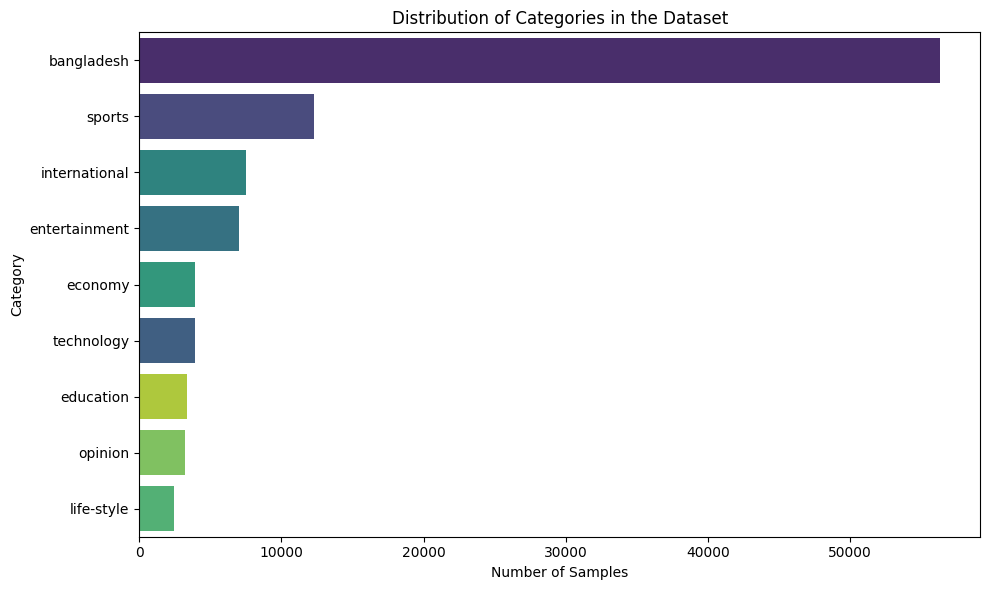

In [16]:
# Plot class distribution
plt.figure(figsize=(10, 6))
sns.countplot(y='category', data=df, order=df['category'].value_counts().index, palette='viridis', hue='category', legend=False)
plt.title('Distribution of Categories in the Dataset')
plt.xlabel('Number of Samples')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

# @title step_artifacts
num_fig = "1" # @param {type:"string"}
step = 'ModelEvaluation'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# Make sure to define `upload_plt_to_gcs` function or remove this line if not used
# upload_plt_to_gcs(num_fig, step, plt)

In [17]:
import re

def clean_text(text):
    text = str(text)

    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"www\S+", "", text)

    text = re.sub(r"[^\u0980-\u09FF\s]", " ", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

df["clean_text"] = df["text"].apply(clean_text)

In [18]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["label"] = encoder.fit_transform(df["category"])

print(dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))

{'bangladesh': np.int64(0), 'economy': np.int64(1), 'education': np.int64(2), 'entertainment': np.int64(3), 'international': np.int64(4), 'life-style': np.int64(5), 'opinion': np.int64(6), 'sports': np.int64(7), 'technology': np.int64(8)}


## 3. Model Architectures and Training

This section should detail the neural network architectures you've employed: CNN, BiLSTM, and the Attention-BiLSTM model. For each model, briefly explain its key components and why it's suitable for text classification. Justify the chosen hyperparameters such as `MAX_WORDS` for the tokenizer, `MAX_LEN` for padding, and batch sizes. Explain the purpose of `EarlyStopping`, `ReduceLROnPlateau`, and `ModelCheckpoint` callbacks in the training process.

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.15,
    random_state=42,
    stratify=df["label"]
)

In [20]:
from tensorflow.keras.preprocessing.text import Tokenizer

MAX_WORDS = 50000

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

In [21]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 400

# Convert text to sequences using the tokenizer
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

print(X_train_pad.shape)

(85000, 400)


In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

cnn_model = Sequential([
    Embedding(MAX_WORDS, 128, input_length=MAX_LEN),

    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),

    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(len(encoder.classes_), activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### CNN Model Architecture

Here's a summary of the Convolutional Neural Network (CNN) model's architecture, outlining each layer and its parameters:

In [23]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

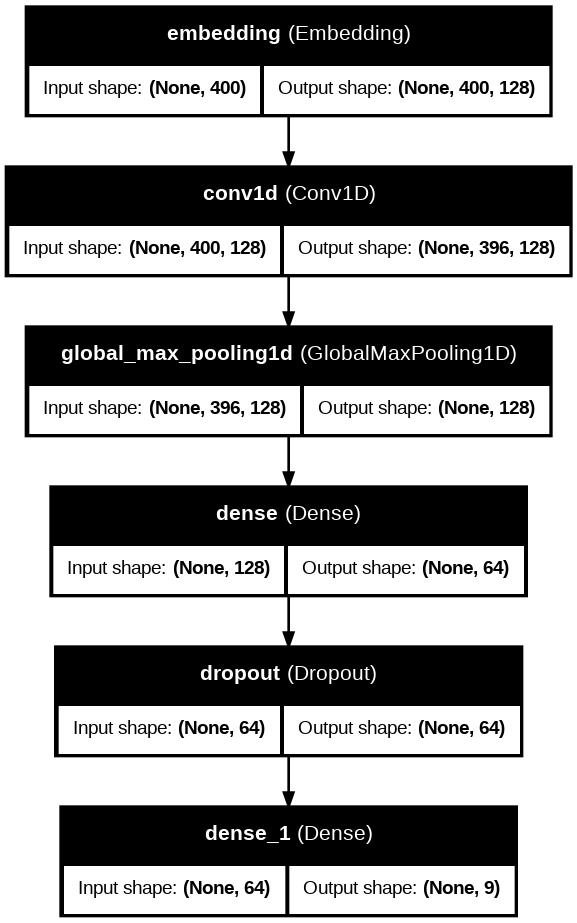

In [24]:
import tensorflow as tf
from IPython.display import Image

# Explicitly build the model before plotting
cnn_model.build(input_shape=(None, MAX_LEN))

# Plot the CNN model architecture
tf.keras.utils.plot_model(
    cnn_model,
    to_file='cnn_model_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    dpi=96
)

# Display the image
Image(filename='cnn_model_architecture.png')

In [25]:
cnn_history = cnn_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.1,
    epochs=5,
    batch_size=128
)

Epoch 1/5
598/598 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.8150 - loss: 0.6183 - val_accuracy: 0.9278 - val_loss: 0.2373
Epoch 2/5
598/598 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9427 - loss: 0.1975 - val_accuracy: 0.9378 - val_loss: 0.2098
Epoch 3/5
598/598 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9719 - loss: 0.0950 - val_accuracy: 0.9406 - val_loss: 0.2181
Epoch 4/5
598/598 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9874 - loss: 0.0449 - val_accuracy: 0.9393 - val_loss: 0.2547
Epoch 5/5
598/598 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9933 - loss: 0.0253 - val_accuracy: 0.9401 - val_loss: 0.2833


In [26]:
bilstm_model = Sequential([
    Embedding(MAX_WORDS, 128, input_length=MAX_LEN),

    Bidirectional(LSTM(64, dropout=0.3)),

    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(len(encoder.classes_), activation='softmax')
])

bilstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


### BiLSTM Model Architecture

Below is the summary and architectural plot for the Bidirectional LSTM (BiLSTM) model, showcasing its layer-by-layer construction:

In [27]:
bilstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

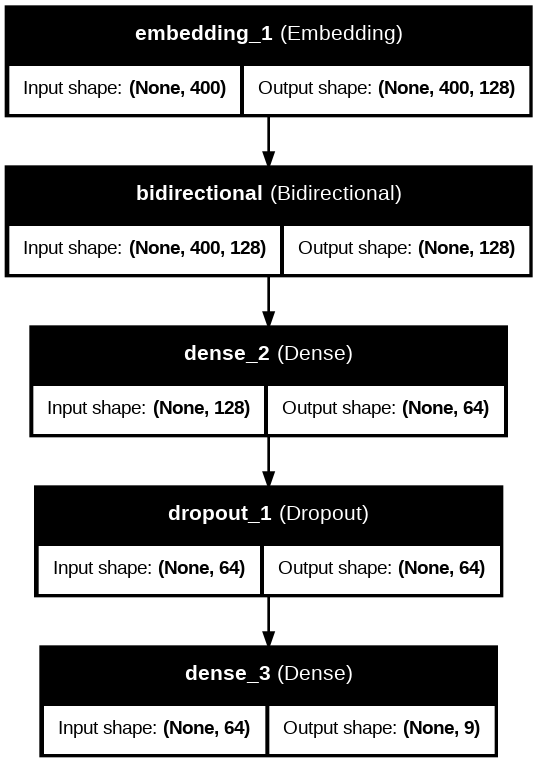

In [28]:
import tensorflow as tf
from IPython.display import Image

# Explicitly build the model before plotting
bilstm_model.build(input_shape=(None, MAX_LEN))

# Plot the BiLSTM model architecture
tf.keras.utils.plot_model(
    bilstm_model,
    to_file='bilstm_model_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    dpi=96
)

# Display the image
Image(filename='bilstm_model_architecture.png')

In [29]:
bilstm_history = bilstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.1,
    epochs=5,
    batch_size=64
)

Epoch 1/5
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 53s 39ms/step - accuracy: 0.7880 - loss: 0.6914 - val_accuracy: 0.8936 - val_loss: 0.3864
Epoch 2/5
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 77s 38ms/step - accuracy: 0.9242 - loss: 0.2654 - val_accuracy: 0.9124 - val_loss: 0.2925
Epoch 3/5
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 46s 39ms/step - accuracy: 0.9544 - loss: 0.1618 - val_accuracy: 0.9182 - val_loss: 0.3029
Epoch 4/5
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 45s 37ms/step - accuracy: 0.9667 - loss: 0.1198 - val_accuracy: 0.9165 - val_loss: 0.3512
Epoch 5/5
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 45s 37ms/step - accuracy: 0.9755 - loss: 0.0903 - val_accuracy: 0.9216 - val_loss: 0.3656


In [30]:
import tensorflow as tf

from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    GlobalAveragePooling1D,
    Attention
)

from tensorflow.keras.models import Model

In [31]:
inputs = Input(shape=(MAX_LEN,))

embedding = Embedding(
    input_dim=MAX_WORDS,
    output_dim=128
)(inputs)

bilstm = Bidirectional(
    LSTM(
        64,
        return_sequences=True,
        dropout=0.3
    )
)(embedding)

attention = Attention()(
    [bilstm, bilstm]
)

pool = GlobalAveragePooling1D()(attention)

dense = Dense(
    64,
    activation='relu'
)(pool)

drop = Dropout(0.5)(dense)

outputs = Dense(
    len(encoder.classes_),
    activation='softmax'
)(drop)

attention_model = Model(
    inputs=inputs,
    outputs=outputs
)

attention_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 400)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 400, 128)  │  6,400,000 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 400, 128)  │     98,816 │ embedding_2[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 400, 128)  │          0 │ bidirectional_1[… │
│ (Attention)         │                   │            │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 9)         │        585 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,507,657 (24.82 MB)

 Trainable params: 6,507,657 (24.82 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
attention_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Attention-BiLSTM Model Architecture

To visually represent the Attention-BiLSTM model, we can generate a diagram that shows its layers and their connections. This diagram is essential for the 'Model Architectures and Training' section of your paper, allowing readers to quickly grasp the structural details of your proposed model.

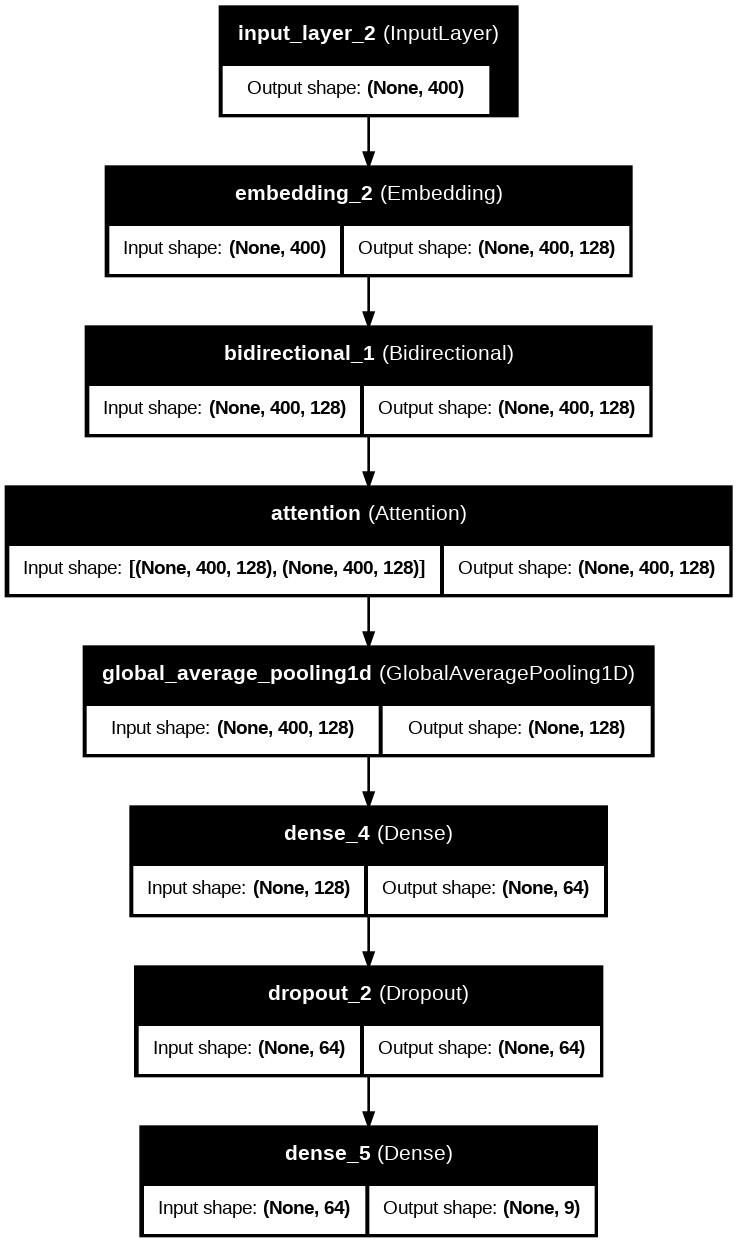

In [33]:
import tensorflow as tf

# Plot the Attention-BiLSTM model architecture
tf.keras.utils.plot_model(
    attention_model,
    to_file='attention_bilstm_model_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    dpi=96
)

# Display the image
from IPython.display import Image
Image(filename='attention_bilstm_model_architecture.png')


In [34]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2
    ),

    ModelCheckpoint(
        "best_attention_model.keras",
        save_best_only=True
    )
]

In [35]:
history = attention_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/15
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 57s 46ms/step - accuracy: 0.8017 - loss: 0.6353 - val_accuracy: 0.9189 - val_loss: 0.2728 - learning_rate: 0.0010
Epoch 2/15
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 55s 46ms/step - accuracy: 0.9423 - loss: 0.2047 - val_accuracy: 0.9346 - val_loss: 0.2266 - learning_rate: 0.0010
Epoch 3/15
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 55s 46ms/step - accuracy: 0.9700 - loss: 0.1078 - val_accuracy: 0.9400 - val_loss: 0.2172 - learning_rate: 0.0010
Epoch 4/15
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 55s 46ms/step - accuracy: 0.9826 - loss: 0.0612 - val_accuracy: 0.9413 - val_loss: 0.2590 - learning_rate: 0.0010
Epoch 5/15
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 54s 45ms/step - accuracy: 0.9888 - loss: 0.0387 - val_accuracy: 0.9347 - val_loss: 0.3093 - learning_rate: 0.0010
Epoch 6/15
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 54s 45ms/step - accuracy: 0.9950 - loss: 0.0195 - val_accuracy: 0.9411 - val_loss: 0.3420 - learning_rate: 5.0000e-04


In [36]:
loss, accuracy = attention_model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print(f"Test Accuracy: {accuracy:.4f}")

469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9436 - loss: 0.1999
Test Accuracy: 0.9436


In [37]:
predictions = attention_model.predict(
    X_test_pad
)

y_pred = predictions.argmax(axis=1)

469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step


In [39]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

               precision    recall  f1-score   support

   bangladesh       0.97      0.97      0.97      8448
      economy       0.84      0.77      0.80       589
    education       0.97      0.87      0.92       498
entertainment       0.92      0.95      0.93      1053
international       0.88      0.94      0.91      1131
   life-style       0.88      0.83      0.85       368
      opinion       0.80      0.86      0.83       486
       sports       0.98      0.98      0.98      1840
   technology       0.90      0.88      0.89       587

     accuracy                           0.94     15000
    macro avg       0.91      0.89      0.90     15000
 weighted avg       0.94      0.94      0.94     15000



## 4. Results and Evaluation




### Resources

This section provides the detailed evaluation metrics for the CNN and BiLSTM models, including test accuracy, classification reports, and confusion matrices.

In [44]:
# Install necessary font (e.g., Noto Sans Bengali)
# Use -qq to suppress output unless there's an error
!apt-get install -y -qq fonts-noto-extra

# Configure matplotlib to use the installed font
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# Clear Matplotlib's font cache and rebuild font list
# This is crucial after installing new fonts.
print("Clearing Matplotlib font cache and rebuilding font list...")
fm.fontManager = fm.FontManager() # Reinitialize font manager to rebuild cache
fm.findSystemFonts(fontpaths=None, fontext='ttf') # Re-scan for system fonts (explicitly call)

bengali_font_path = None
font_name = None

# Search for Noto Bengali fonts in the system fonts known to Matplotlib
found_noto_bengali = False
search_terms = ['noto', 'bengali'] # Look for fonts containing both terms

for font in fm.fontManager.ttflist:
    # Check if all search terms are in the font's name (case-insensitive)
    if all(term in font.name.lower() for term in search_terms):
        bengali_font_path = font.fname
        font_name = font.name
        found_noto_bengali = True
        break

if found_noto_bengali:
    # Set rcParams to use this font
    plt.rcParams['font.sans-serif'] = [font_name, 'DejaVu Sans', 'Arial'] # Prioritize Noto Bengali
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['axes.unicode_minus'] = False # Important for displaying '-' correctly with Unicode fonts

    print(f"Successfully configured Matplotlib to use font: {font_name} from {bengali_font_path}")
else:
    print("Could not find Noto Bengali font by explicit name in Matplotlib's font manager.")
    print("Listing all fonts containing 'noto' or 'bengali' to aid debugging:")
    found_any_bengali = False
    for font in fm.fontManager.ttflist:
        if any(term in font.name.lower() for term in search_terms):
            print(f"  Found: {font.name} (File: {font.fname})")
            found_any_bengali = True

    if not found_any_bengali:
        print("No fonts containing 'noto' or 'bengali' found in Matplotlib's font manager.")
        print("Please ensure 'fonts-noto-extra' is installed correctly and check font paths.")

    # Fallback to general sans-serif if specific Bengali font not found or identified
    print("Falling back to default sans-serif, which might not render Bengali characters correctly.")
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['axes.unicode_minus'] = False

# Re-run the confusion matrix plot or explanation plot after this cell to see the effect
# For example, if your confusion matrix plot was in cell BTjw_zacjoHb, re-execute that cell.
# The `explain_text` function in cell XrpnU5hSjpxv would also benefit from this.


Clearing Matplotlib font cache and rebuilding font list...
Successfully configured Matplotlib to use font: Noto Serif Bengali from /usr/share/fonts/truetype/noto/NotoSerifBengali-SemiCondensedMedium.ttf


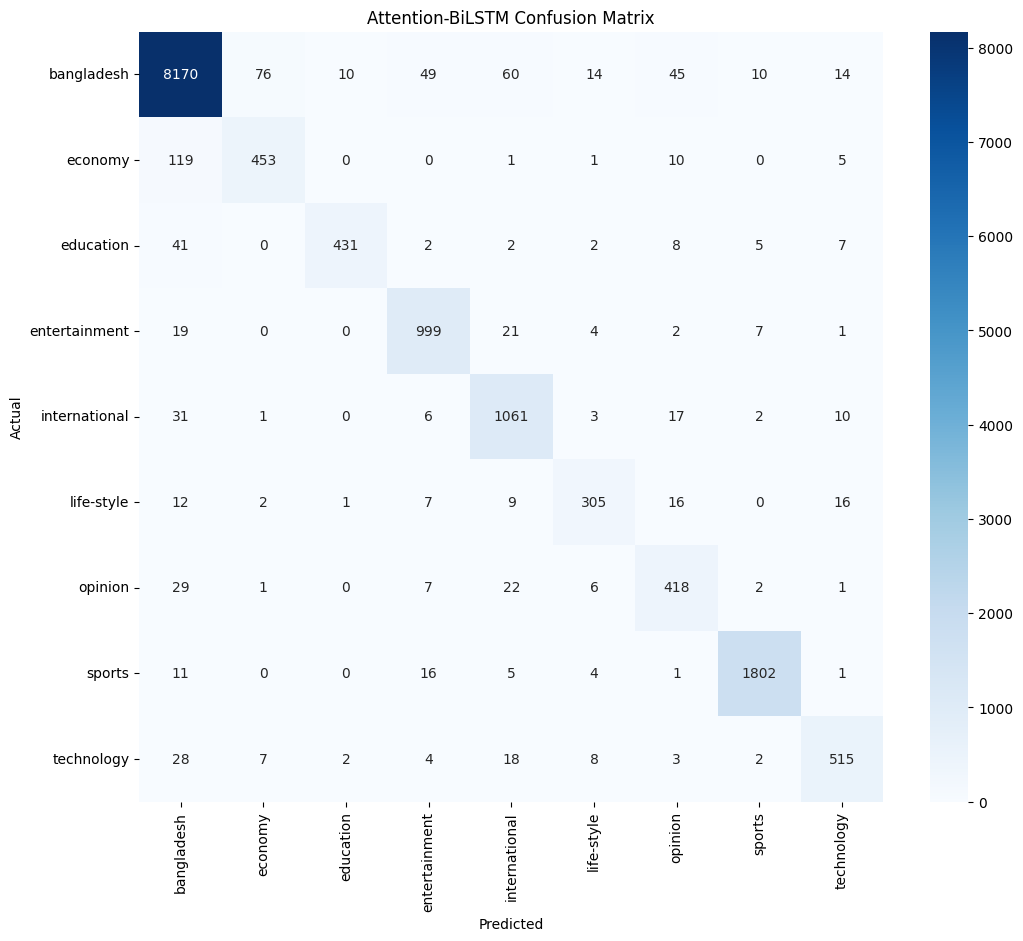

In [55]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Attention-BiLSTM Confusion Matrix")

plt.show()

#### CNN Model Evaluation

In [40]:
loss_cnn, accuracy_cnn = cnn_model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print(f"CNN Test Accuracy: {accuracy_cnn:.4f}")
print(f"CNN Test Loss: {loss_cnn:.4f}")

469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9426 - loss: 0.2544
CNN Test Accuracy: 0.9426
CNN Test Loss: 0.2544


In [41]:
from sklearn.metrics import classification_report

predictions_cnn = cnn_model.predict(X_test_pad)
y_pred_cnn = predictions_cnn.argmax(axis=1)

print("CNN Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_cnn,
        target_names=encoder.classes_
    )
)

469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
CNN Classification Report:
               precision    recall  f1-score   support

   bangladesh       0.96      0.97      0.97      8448
      economy       0.84      0.75      0.79       589
    education       0.95      0.91      0.93       498
entertainment       0.91      0.95      0.93      1053
international       0.92      0.92      0.92      1131
   life-style       0.88      0.82      0.85       368
      opinion       0.84      0.77      0.80       486
       sports       0.98      0.98      0.98      1840
   technology       0.88      0.91      0.89       587

     accuracy                           0.94     15000
    macro avg       0.90      0.89      0.89     15000
 weighted avg       0.94      0.94      0.94     15000



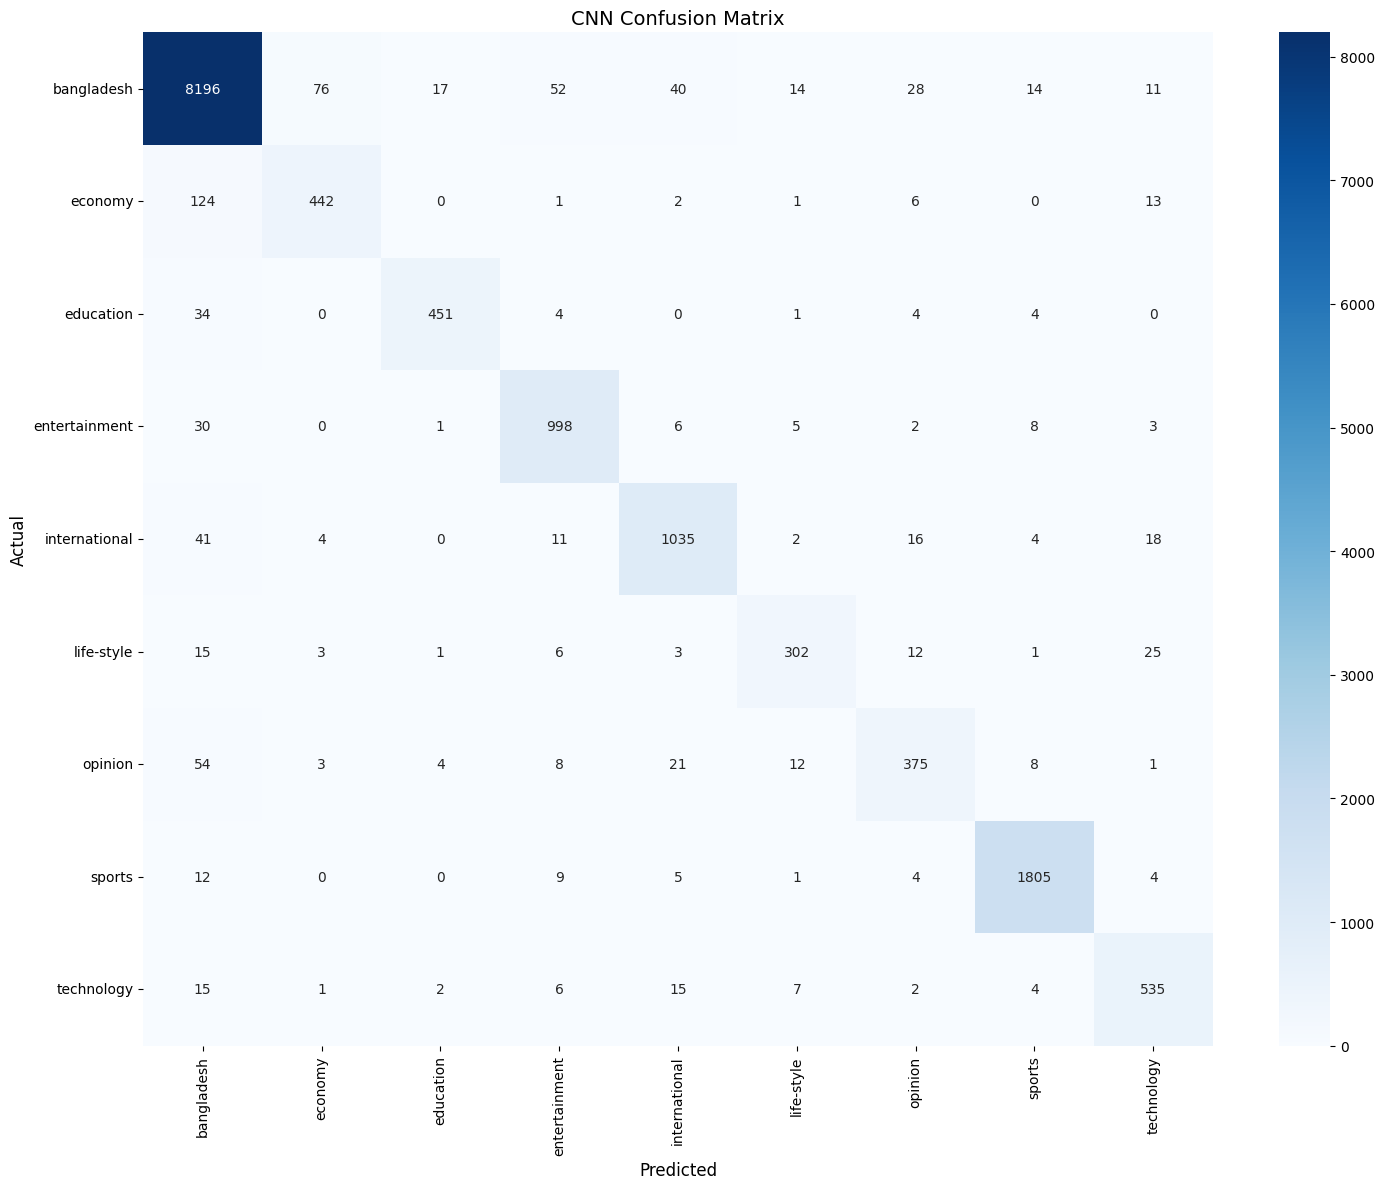

In [46]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm # Import font_manager

cm_cnn = confusion_matrix(
    y_test,
    y_pred_cnn
)

plt.figure(figsize=(15,12)) # Increased figure size for better readability

sns.heatmap(
    cm_cnn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_, # Use encoder.classes_ for English class names
    yticklabels=encoder.classes_, # Use encoder.classes_ for English class names
    annot_kws={"fontsize": 10} # Fontsize for annotations inside cells
)

# Using default sans-serif for axis labels and applying rotation and fontsize
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10) # rotation=0 for horizontal

plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.title("CNN Confusion Matrix", fontsize=14)

plt.tight_layout()
plt.show()

#### BiLSTM Model Evaluation

In [47]:
loss_bilstm, accuracy_bilstm = bilstm_model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print(f"BiLSTM Test Accuracy: {accuracy_bilstm:.4f}")
print(f"BiLSTM Test Loss: {loss_bilstm:.4f}")

469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9244 - loss: 0.3470
BiLSTM Test Accuracy: 0.9244
BiLSTM Test Loss: 0.3470


In [57]:
from sklearn.metrics import classification_report

predictions_bilstm = bilstm_model.predict(X_test_pad)
y_pred_bilstm = predictions_bilstm.argmax(axis=1)

print("BiLSTM Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_bilstm,
        target_names=encoder.classes_
    )
)

469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step
BiLSTM Classification Report:
               precision    recall  f1-score   support

   bangladesh       0.96      0.96      0.96      8448
      economy       0.74      0.78      0.76       589
    education       0.93      0.88      0.91       498
entertainment       0.91      0.91      0.91      1053
international       0.89      0.89      0.89      1131
   life-style       0.69      0.82      0.75       368
      opinion       0.77      0.66      0.71       486
       sports       0.97      0.97      0.97      1840
   technology       0.87      0.87      0.87       587

     accuracy                           0.92     15000
    macro avg       0.86      0.86      0.86     15000
 weighted avg       0.93      0.92      0.92     15000



469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step


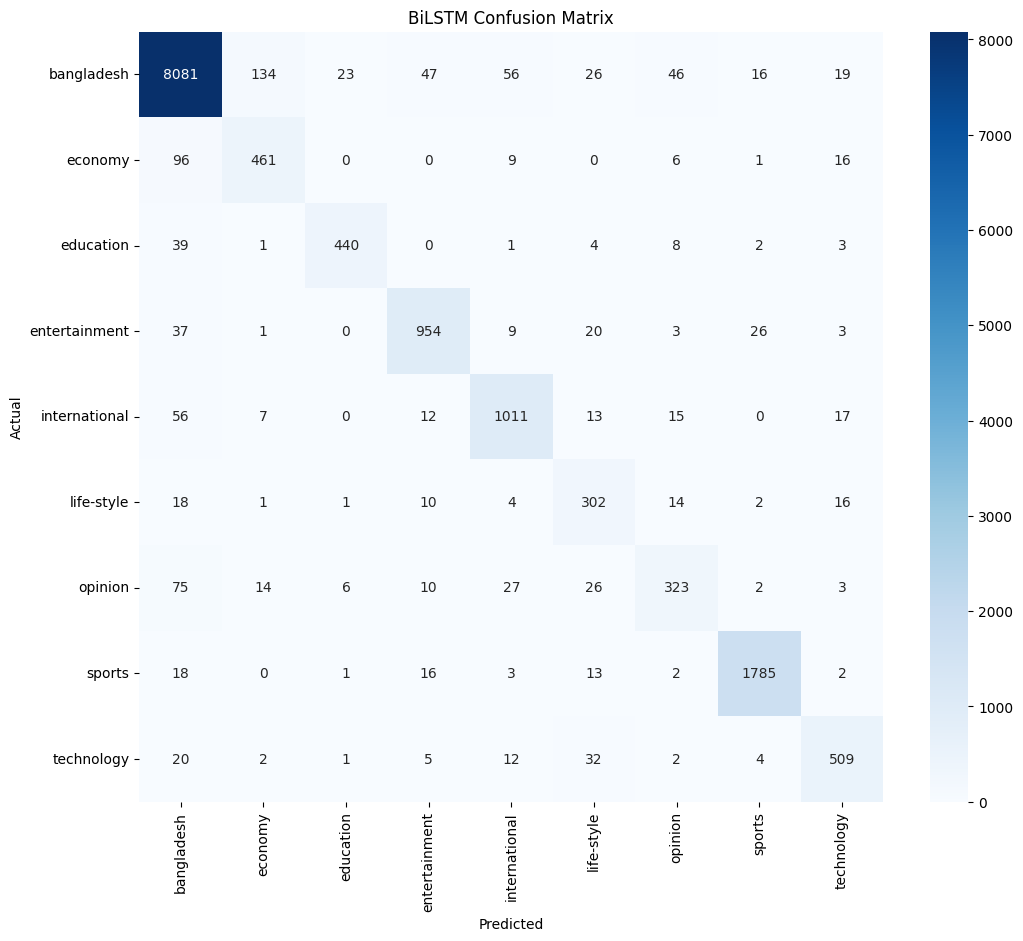

In [56]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

predictions_bilstm = bilstm_model.predict(X_test_pad)
y_pred_bilstm = predictions_bilstm.argmax(axis=1)

cm_bilstm = confusion_matrix(
    y_test,
    y_pred_bilstm
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm_bilstm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BiLSTM Confusion Matrix")

plt.show()

## 5. Explainability Analysis

This section is crucial for the 'Explainable' aspect of your research. Describe the gradient-based explanation method implemented in your `explain_text` function. Explain what the 'Normalized token importance' represents and how it helps in understanding the model's decision-making process for specific predictions. Analyze the example provided by `explain_text`, discussing whether the identified top contributing Bangla tokens intuitively align with the predicted category. Provide insights into how this explainability can be useful for debugging the model, gaining trust, or understanding linguistic patterns.


Actual label: bangladesh
Predicted label: bangladesh
Confidence: 0.9996
Top contributing Bangla tokens:
উপজেলার: 1.0000
কর্তৃপক্ষের: 0.7266
গতকাল: 0.3092
পার্বতীপুর: 0.2457
দফা: 0.2297
শিলা: 0.2060
খনির: 0.1996
কঠিন: 0.1910
খনি: 0.1906
সোমবার: 0.1879
ছাড়া: 0.1873
নয়: 0.1862
Using font from path: /usr/share/fonts/truetype/noto/NotoSansBengali-Light.ttf


/tmp/ipykernel_11112/2957619994.py:90: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/tmp/ipykernel_11112/2957619994.py:90: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Bengali.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Bengali.
  fig.canvas.print_figure(bytes_io, **kw)


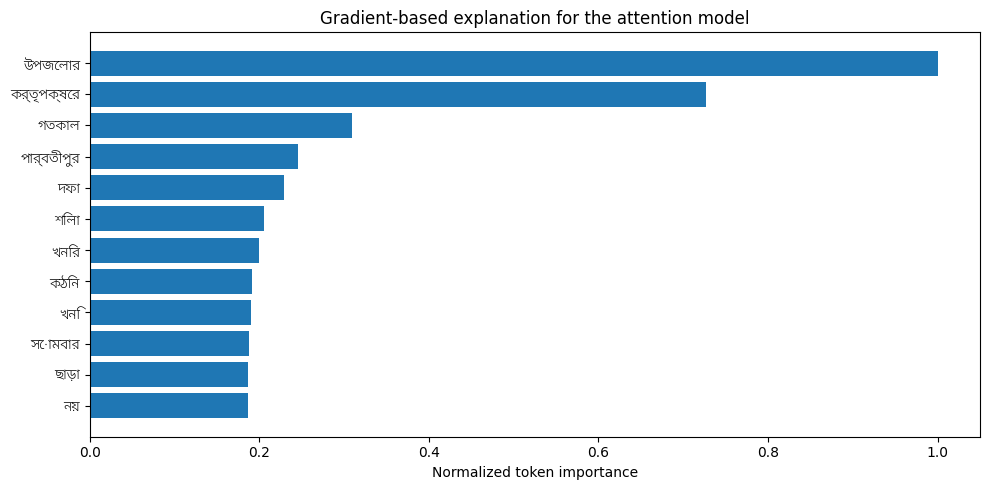

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import matplotlib.font_manager as fm # Import font_manager

reverse_word_index = {index: word for word, index in tokenizer.word_index.items()}

bengali_class_names = encoder.classes_

def explain_text(text, model=attention_model, top_k=12):
    cleaned_text = clean_text(text)
    sequence = tokenizer.texts_to_sequences([cleaned_text])
    padded = pad_sequences(sequence, maxlen=MAX_LEN, padding="post", truncating="post")
    input_tensor = tf.convert_to_tensor(padded)

    embedding_layer = model.layers[1]
    bilstm_layer = model.layers[2]
    attention_layer = model.layers[3]
    pool_layer = model.layers[4]
    dense_layer = model.layers[5]
    dropout_layer = model.layers[6]
    output_layer = model.layers[7]

    with tf.GradientTape() as tape:
        embeddings = embedding_layer(input_tensor)
        tape.watch(embeddings)
        sequence_output = bilstm_layer(embeddings, training=False)
        attention_output = attention_layer([sequence_output, sequence_output])
        pooled_output = pool_layer(attention_output)
        dense_output = dense_layer(pooled_output)
        dropout_output = dropout_layer(dense_output, training=False)
        probabilities = output_layer(dropout_output, training=False)
        predicted_class = tf.argmax(probabilities[0])
        class_score = probabilities[:, predicted_class]

    gradients = tape.gradient(class_score, embeddings)[0]
    token_scores = tf.reduce_sum(tf.abs(gradients) * tf.abs(embeddings[0]), axis=-1).numpy()

    tokens = [reverse_word_index.get(int(token_id), "") for token_id in padded[0] if int(token_id) != 0]
    token_scores = token_scores[:len(tokens)]

    valid_tokens = []
    valid_scores = []
    for token, score in zip(tokens, token_scores):
        if token.strip():
            valid_tokens.append(token)
            valid_scores.append(float(score))

    if not valid_tokens:
        print("No explainable tokens found for this sample.")
        return

    scores = np.array(valid_scores, dtype=float)
    if scores.max() > 0:
        scores = scores / scores.max()

    top_indices = np.argsort(scores)[-min(top_k, len(scores)):]
    top_tokens = [valid_tokens[i] for i in top_indices]
    top_scores = scores[top_indices]

    # Use bengali_class_names to get the correct label
    predicted_label = bengali_class_names[int(predicted_class.numpy())]
    predicted_probability = float(tf.reduce_max(probabilities).numpy())

    print(f"Predicted label: {predicted_label}")
    print(f"Confidence: {predicted_probability:.4f}")
    print("Top contributing Bangla tokens:")

    ranked = sorted(zip(top_tokens, top_scores), key=lambda item: item[1], reverse=True)
    for token, score in ranked:
        print(f"{token}: {score:.4f}")

    plt.figure(figsize=(10, 5))

    # Rely on global rcParams for font handling, which includes fallbacks.
    # The bengali_font_path logic is no longer needed here as rcParams handle it.

    ordered_indices = np.argsort(top_scores)
    plt.barh(np.array(top_tokens)[ordered_indices], top_scores[ordered_indices], color="#1f77b4")

    # Apply sans-serif font family, letting rcParams handle primary and fallback fonts
    plt.yticks(fontfamily='sans-serif')
    plt.xlabel("Normalized token importance", fontfamily='sans-serif')
    plt.title("Gradient-based explanation for the attention model", fontfamily='sans-serif')
    plt.tight_layout()
    plt.show()

sample_index = 0
sample_text = X_test.iloc[sample_index]
print("Actual label:", bengali_class_names[int(y_test.iloc[sample_index])]) # Use bengali_class_names
explain_text(sample_text)

In [60]:
attention_model.save(
    "/content/drive/MyDrive/attention_bilstm_bangla.keras"
)

In [61]:
import pickle

with open(
    "/content/drive/MyDrive/tokenizer.pkl",
    "wb"
) as f:

    pickle.dump(
        tokenizer,
        f
    )

### Another XAI Example

Let's examine another sample from the test set to see how the model makes predictions for a different category and what tokens contribute most to that decision.

Actual label: bangladesh
Predicted label: bangladesh
Confidence: 0.9994
Top contributing Bangla tokens:
জানতে: 1.0000
কেন: 0.9289
মতিউর: 0.8570
সেক্রেটারি: 0.7629
না: 0.7337
জামায়াতের: 0.6996
চাওয়া: 0.6736
করা: 0.6502
প্রকাশিত: 0.6433
তা: 0.5921
আমির: 0.5785
জেনারেল: 0.5489
Using font from path: /usr/share/fonts/truetype/noto/NotoSansBengali-Light.ttf


/tmp/ipykernel_11112/2957619994.py:90: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/tmp/ipykernel_11112/2957619994.py:90: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Bengali.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Bengali.
  fig.canvas.print_figure(bytes_io, **kw)


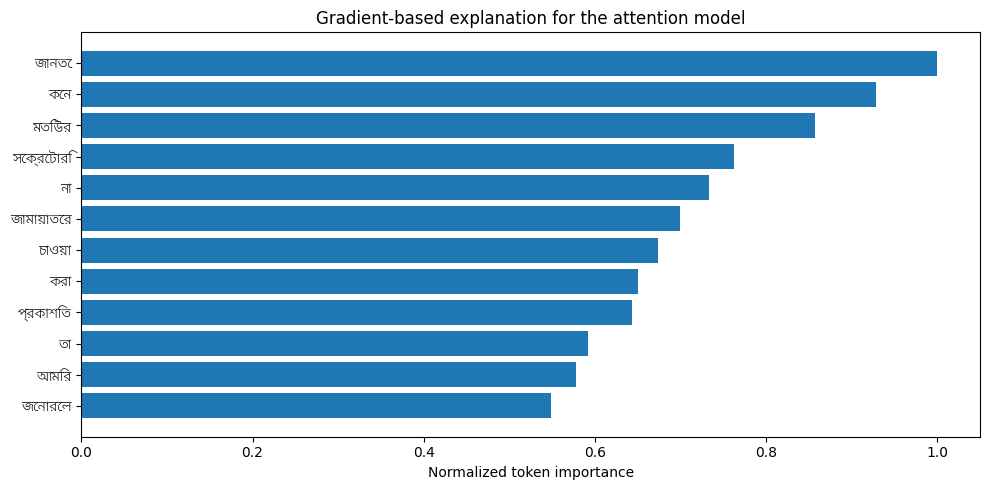

In [62]:
sample_index_2 = 1
sample_text_2 = X_test.iloc[sample_index_2]
print("Actual label:", bengali_class_names[int(y_test.iloc[sample_index_2])]) # Use bengali_class_names
explain_text(sample_text_2)

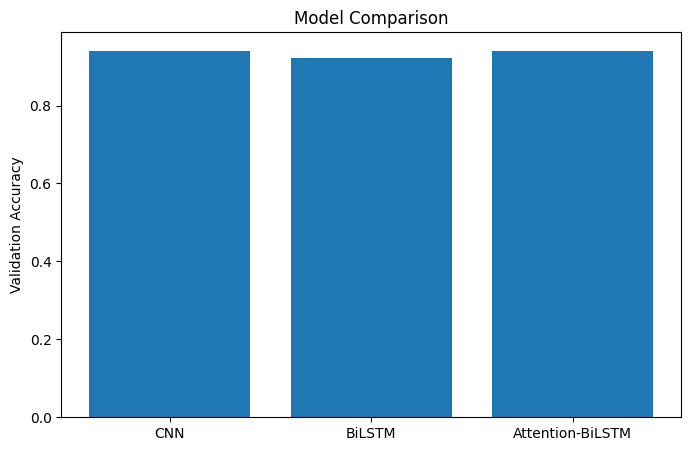

In [63]:
models = [
    "CNN",
    "BiLSTM",
    "Attention-BiLSTM"
]

accuracies = [
    cnn_history.history['val_accuracy'][-1],
    bilstm_model.history.history['val_accuracy'][-1] if hasattr(bilstm_model, 'history') else 0,
    history.history['val_accuracy'][-1]
]

plt.figure(figsize=(8,5))

plt.bar(
    models,
    accuracies
)

plt.title("Model Comparison")
plt.ylabel("Validation Accuracy")

plt.show()